In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import yfinance as yf # Dit is de standaard voor beursdata

# 1. Haal 2 jaar aan data op van de AEX of S&P 500
ticker = "^GSPC" # S&P 500 index
data = yf.download(ticker, start="2022-01-01", end="2024-01-01")
prices = data['Close'].values.flatten() # De slotkoersen

print(f"Data van {ticker} succesvol opgehaald. Aantal datapunten: {len(prices)}")


[*********************100%***********************]  1 of 1 completed

Data van ^GSPC succesvol opgehaald. Aantal datapunten: 501


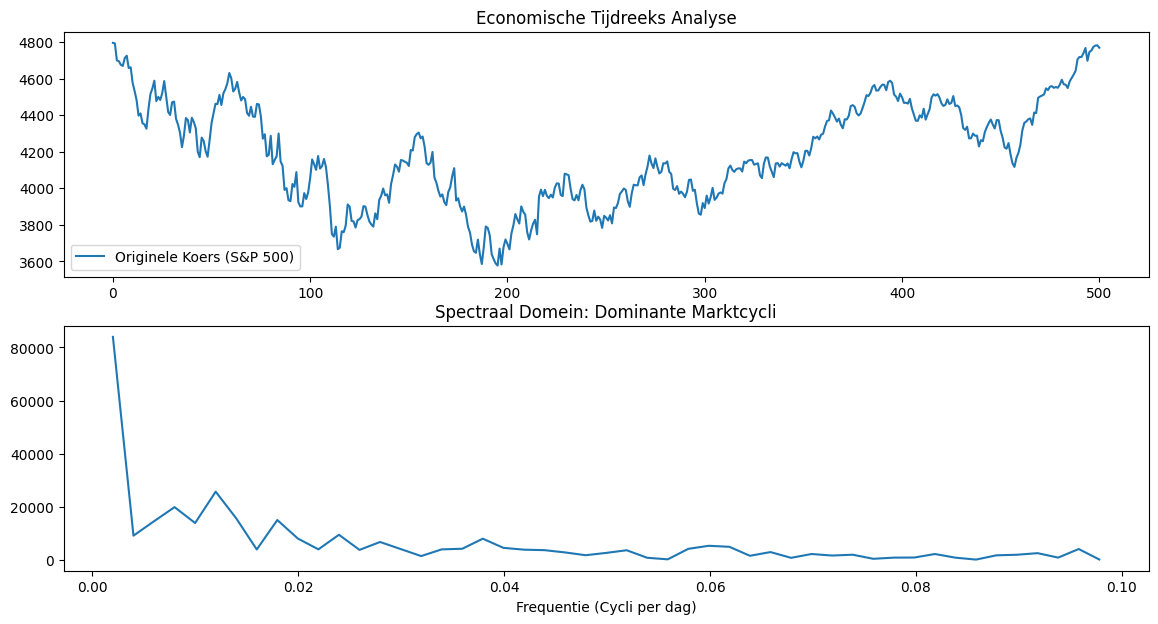

In [8]:
# 2. Fourier Transformatie van de koersdata
N = len(prices)
# Verwijder de trend (detrending) om de oscillaties te zien
prices_detrended = prices - np.linspace(prices[0], prices[-1], N)

yf_signal = fft(prices_detrended)
xf = fftfreq(N, 1)[:N//2] # Frequenties in cycli per dag

# 3. Visualisatie
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(prices, label='Originele Koers (S&P 500)')
plt.title('Economische Tijdreeks Analyse')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(xf[1:50], np.abs(yf_signal[1:50])) # We negeren de 0-frequentie
plt.title('Spectraal Domein: Dominante Marktcycli')
plt.xlabel('Frequentie (Cycli per dag)')
plt.show()


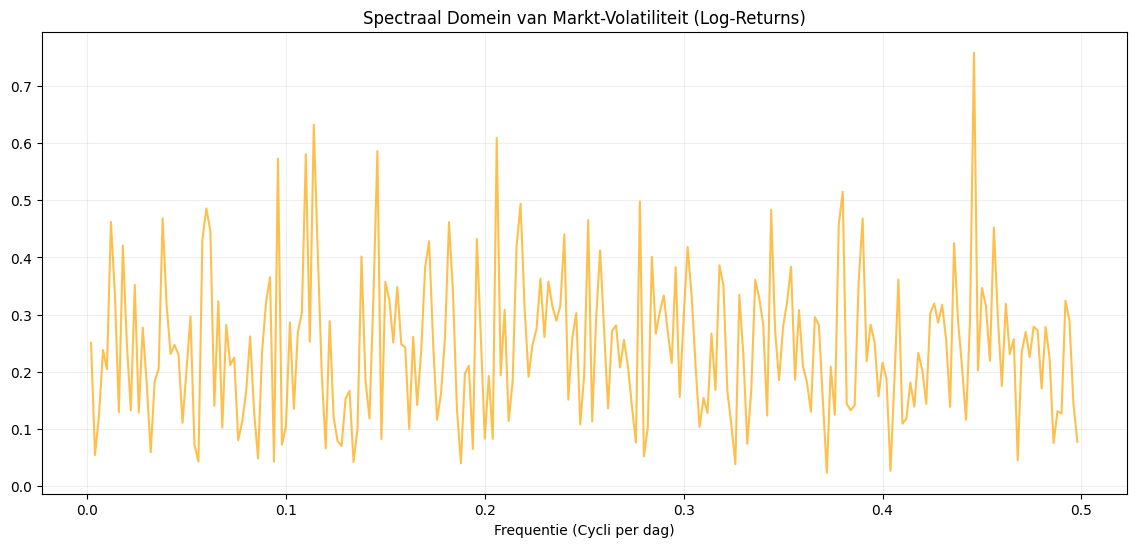

In [9]:
# 1. Bereken Log-Returns: log(P_t / P_{t-1})
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
returns = data['Log_Returns'].dropna()

# 2. Fourier Analyse op de Returns (de volatiliteit)
N_ret = len(returns)
yf_ret = fft(returns.values)
xf_ret = fftfreq(N_ret, 1)[:N_ret//2]

# 3. Visualisatie
plt.figure(figsize=(14, 6))
plt.plot(xf_ret[1:], np.abs(yf_ret[1:N_ret//2]), color='orange', alpha=0.7)
plt.title('Spectraal Domein van Markt-Volatiliteit (Log-Returns)')
plt.xlabel('Frequentie (Cycli per dag)')
plt.grid(True, alpha=0.2)
plt.show()


### 2.1 Spectrale Analyse van Markt-Volatiliteit
In de econometrie is het essentieel om trends te scheiden van stochastische fluctuaties. Door de overstap van absolute koersen naar **Log-Returns** maken we de tijdreeks stationair:

$$r_t = \ln(P_t / P_{t-1})$$

Middels de FFT analyseren we of er verborgen periodiciteit in de marktvolatiliteit zit. Voor **fraudedetectie** is dit cruciaal: legitieme marktdata vertonen vaak een specifiek spectraal 'vingerafdruk'. Een plotselinge verschuiving in dit spectrum kan duiden op algoritmische manipulatie of systeemfouten.


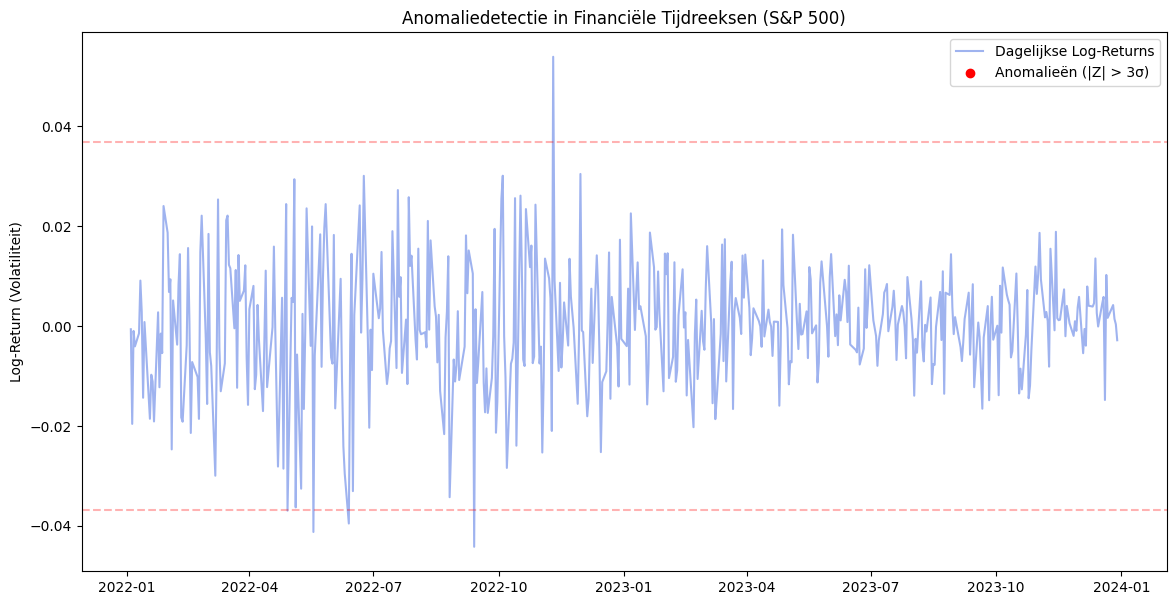

Aantal gedetecteerde anomalieën: 0


In [10]:
# 1. Berekening van het voortschrijdend gemiddelde en standaarddeviatie (Rolling Statistics)
window = 20 # We kijken steeds naar een venster van 20 handelsdagen
rolling_mean = returns.rolling(window=window).mean()
rolling_std = returns.rolling(window=window).std()

# 2. Bereken de Z-score: Hoeveel standaarddeviaties wijkt de dagkoers af?
z_scores = (returns - rolling_mean) / rolling_std

# 3. Identificeer anomalieën (Threshold: |Z| > 3)
anomalies = returns[np.abs(z_scores) > 3]

# 4. Visualisatie: De 'Fraudeblik'
plt.figure(figsize=(14, 7))
plt.plot(returns.index, returns, label='Dagelijkse Log-Returns', color='royalblue', alpha=0.5)
plt.scatter(anomalies.index, anomalies, color='red', label='Anomalieën (|Z| > 3σ)', zorder=5)

plt.axhline(3*returns.std(), color='red', linestyle='--', alpha=0.3)
plt.axhline(-3*returns.std(), color='red', linestyle='--', alpha=0.3)

plt.title('Anomaliedetectie in Financiële Tijdreeksen (S&P 500)')
plt.ylabel('Log-Return (Volatiliteit)')
plt.legend()
plt.show()

print(f"Aantal gedetecteerde anomalieën: {len(anomalies)}")


### 2.2 Statistische Anomaliedetectie middels Z-scores
Om structurele afwijkingen in de marktvolatiliteit te kwantificeren, passen we een **Z-score analyse** toe op de log-returns ($r_t$). De Z-score is gedefinieerd als:

$$z = \frac{x - \mu}{\sigma}$$

waarbij $\mu$ het voortschrijdend gemiddelde is en $\sigma$ de standaarddeviatie. We hanteren de **3$\sigma$-regel** als drempelwaarde voor anomalieën. Punten buiten dit interval duiden op gebeurtenissen met een extreem lage waarschijnlijkheid binnen een Gaussische verdeling. In een context van de Belastingdienst of Bankwezen vormen deze rode punten de eerste indicatie voor **fraude-onderzoek** of **extreme risico-expositie**.
